Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

Load the dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


setting the paths


In [4]:
import pandas as pd

base_path = "/content/drive/MyDrive/cassava-leaf-disease-classification (Unzipped Files)"

df = pd.read_csv(base_path + "/train.csv")

df["image_path"] = base_path + "/train_images/" + df["image_id"]
df.head()

,image_id,label,image_path
0,1000015157.jpg,0,/content/drive/MyDrive/cassava-leaf-disease-cl...
1,1000201771.jpg,3,/content/drive/MyDrive/cassava-leaf-disease-cl...
2,100042118.jpg,1,/content/drive/MyDrive/cassava-leaf-disease-cl...
3,1000723321.jpg,1,/content/drive/MyDrive/cassava-leaf-disease-cl...
4,1000812911.jpg,3,/content/drive/MyDrive/cassava-leaf-disease-cl...


In [5]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)


In [48]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)


In [7]:
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)

train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(256, 256),
    class_mode="categorical",
    batch_size=16,
    shuffle=True
)

val_data = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=(256, 256),
    class_mode="categorical",
    batch_size=16,
    shuffle=False
)


Found 295 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 16822 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


Found 74 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 4206 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


In [43]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_df['label'].astype(int)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)



{0: np.float64(3.934942528735632), 1: np.float64(1.9551113649343232), 2: np.float64(1.7932949188056575), 3: np.float64(0.3252327569827095), 4: np.float64(1.6610383309073264)}


In [49]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)

base_model.trainable = False


In [15]:
import os

def check_image_exists(image_path):
    return os.path.exists(image_path)

# Verify image paths in train_df
train_df['image_exists'] = train_df['image_path'].apply(check_image_exists)
print("Train DataFrame image existence check:")
print(train_df['image_exists'].value_counts())

# Verify image paths in val_df
val_df['image_exists'] = val_df['image_path'].apply(check_image_exists)
print("\nValidation DataFrame image existence check:")
print(val_df['image_exists'].value_counts())

Train DataFrame image existence check:
image_exists
False    16822
True       295
Name: count, dtype: int64

Validation DataFrame image existence check:
image_exists
False    4206
True       74
Name: count, dtype: int64


In [8]:
num_classes = len(train_data.class_indices)


In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=15,
    min_lr=1e-7
)


model 1:CNN

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(256,256,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1=model_1.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop, lr_reduce]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 606ms/step - accuracy: 0.5220 - loss: 2.3548 - val_accuracy: 0.5541 - val_loss: 1.4722 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 654ms/step - accuracy: 0.6203 - loss: 1.2228 - val_accuracy: 0.5541 - val_loss: 1.2891 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 379ms/step - accuracy: 0.6203 - loss: 1.2044 - val_accuracy: 0.5541 - val_loss: 1.2877 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 439ms/step - accuracy: 0.6203 - loss: 1.1972 - val_accuracy: 0.5541 - val_loss: 1.2664 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 420ms/step - accuracy: 0.6203 - loss: 1.1717 - val_accuracy: 0.5541 - val_loss: 1.3350 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 376ms/step - accuracy: 0.6203 - loss: 1.2062 - val_accuracy: 0.5541 - val_loss: 1.5438 - learning_rate: 0.0010
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 459ms/step - accuracy: 0.6237 - loss: 1.1942 

MODEL 2 — TRANSFER LEARNING (EfficientNetB0 ⭐ BEST)

In [30]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)

base_model.trainable = False


In [31]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

model_2 = Model(inputs=base_model.input, outputs=output)

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)




In [50]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [51]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=loss_fn,
    metrics=['accuracy']
)


In [52]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)


In [53]:
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weights   # 🔥 IMPORTANT
)


Epoch 1/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.1695 - loss: 1.7216 - val_accuracy: 0.1351 - val_loss: 1.5987 - learning_rate: 0.0010
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 391ms/step - accuracy: 0.2271 - loss: 1.7013 - val_accuracy: 0.5541 - val_loss: 1.5075 - learning_rate: 0.0010
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 489ms/step - accuracy: 0.2508 - loss: 1.7006 - val_accuracy: 0.0676 - val_loss: 1.6012 - learning_rate: 0.0010
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 390ms/step - accuracy: 0.2034 - loss: 1.6537 - val_accuracy: 0.5541 - val_loss: 1.5798 - learning_rate: 0.0010
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 488ms/step - accuracy: 0.2000 - loss: 1.6859 - val_accuracy: 0.0676 - val_loss: 1.5923 - learning_rate: 0.0010
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 444ms/step - accuracy: 0.2034 - loss: 1.6644 - val_accuracy: 0.5541 - val_loss: 1.5824 - learning_rate: 0.0010
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 397ms/step - accuracy: 0.1220 - loss: 1.6570 - va

In [55]:
history3 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weights
)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 503ms/step - accuracy: 0.2949 - loss: 1.6910 - val_accuracy: 0.5541 - val_loss: 1.5233 - learning_rate: 2.7000e-05
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 392ms/step - accuracy: 0.2102 - loss: 1.7530 - val_accuracy: 0.5541 - val_loss: 1.5400 - learning_rate: 2.7000e-05
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 473ms/step - accuracy: 0.3017 - loss: 1.6767 - val_accuracy: 0.5541 - val_loss: 1.5508 - learning_rate: 2.7000e-05
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 396ms/step - accuracy: 0.2441 - loss: 1.6738 - val_accuracy: 0.5541 - val_loss: 1.5586 - learning_rate: 2.7000e-05
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 428ms/step - accuracy: 0.2203 - loss: 1.6747 - val_accuracy: 0.5541 - val_loss: 1.5599 - learning_rate: 2.7000e-05
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 456ms/step - accuracy: 0.2271 - loss: 1.6692 - val_accuracy: 0.5541 - val_loss: 1.5615 - learning_rate: 8.1000e-06
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 383ms/step - accuracy: 

In [54]:
base_model.trainable = True

# Unfreeze top layers only
for layer in base_model.layers[:-50]:
    layer.trainable = False


In [56]:
val_data.reset()
pred = model.predict(val_data)
y_pred = np.argmax(pred, axis=1)

print(np.bincount(y_pred))


5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step
[ 0  0  0 74]


In [32]:
history2=model_2.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.5966 - loss: 1.2902 - val_accuracy: 0.5541 - val_loss: 1.3060 - learning_rate: 0.0010
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 378ms/step - accuracy: 0.6203 - loss: 1.2228 - val_accuracy: 0.5541 - val_loss: 1.2961 - learning_rate: 0.0010
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.6203 - loss: 1.2105 - val_accuracy: 0.5541 - val_loss: 1.4268 - learning_rate: 0.0010
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 368ms/step - accuracy: 0.6203 - loss: 1.2392 - val_accuracy: 0.5541 - val_loss: 1.2941 - learning_rate: 0.0010
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.6203 - loss: 1.2336 - val_accuracy: 0.5541 - val_loss: 1.3018 - learning_rate: 0.0010
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 411ms/step - accuracy: 0.6203 - loss: 1.2256 - val_accuracy: 0.5541 - val_loss: 1.3366 - learning_rate: 0.0010
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 402ms/step - accuracy: 0.6203 - loss: 1.2191 - va

MODEL 3 — FINE TUNING (VERY IMPORTANT)

In [20]:
base_model.trainable = True

# freeze early layers
for layer in base_model.layers[:-40]:
    layer.trainable = False


In [21]:
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [22]:
history3 = model_2.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop, lr_reduce]
)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.3729 - loss: 1.5946 - val_accuracy: 0.5541 - val_loss: 1.3108 - learning_rate: 1.0000e-05
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 609ms/step - accuracy: 0.5288 - loss: 1.4327 - val_accuracy: 0.5541 - val_loss: 1.3156 - learning_rate: 1.0000e-05
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 464ms/step - accuracy: 0.5458 - loss: 1.3741 - val_accuracy: 0.5541 - val_loss: 1.3212 - learning_rate: 1.0000e-05
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 420ms/step - accuracy: 0.5966 - loss: 1.2960 - val_accuracy: 0.5541 - val_loss: 1.3264 - learning_rate: 1.0000e-05
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 537ms/step - accuracy: 0.6102 - loss: 1.2637 - val_accuracy: 0.5541 - val_loss: 1.3308 - learning_rate: 1.0000e-05
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 435ms/step - accuracy: 0.6102 - loss: 1.2381 - val_accuracy: 0.5541 - val_loss: 1.3333 - learning_rate: 1.0000e-05
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 406ms/step - accuracy: 

In [44]:
history3 = model_2.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop, lr_reduce],
    class_weight=class_weights
)


Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.3390 - loss: 1.7672 - val_accuracy: 0.1216 - val_loss: 1.6804 - learning_rate: 3.0000e-04
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 382ms/step - accuracy: 0.1085 - loss: 1.6779 - val_accuracy: 0.0676 - val_loss: 1.6282 - learning_rate: 3.0000e-04
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 475ms/step - accuracy: 0.1898 - loss: 1.6654 - val_accuracy: 0.1351 - val_loss: 1.6197 - learning_rate: 3.0000e-04
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 638ms/step - accuracy: 0.2373 - loss: 1.6530 - val_accuracy: 0.0676 - val_loss: 1.5916 - learning_rate: 3.0000e-04
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 370ms/step - accuracy: 0.1729 - loss: 1.6332 - val_accuracy: 0.0676 - val_loss: 1.6261 - learning_rate: 3.0000e-04
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 562ms/step - accuracy: 0.2034 - loss: 1.6313 - val_accuracy: 0.0676 - val_loss: 1.5874 - learning_rate: 3.0000e-04
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 480ms/step - accuracy: 

In [45]:
train_df['label'].value_counts()


,count
label,
3,10526
4,2061
2,1909
1,1751
0,870


In [46]:
val_data.reset()
pred_probs = model_2.predict(val_data)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step


In [47]:
print(np.bincount(y_pred))


[ 0  0  0 74]


In [23]:
import matplotlib.pyplot as plt


In [28]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure()

    # Accuracy plot
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

    plt.figure()

    # Loss plot
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()


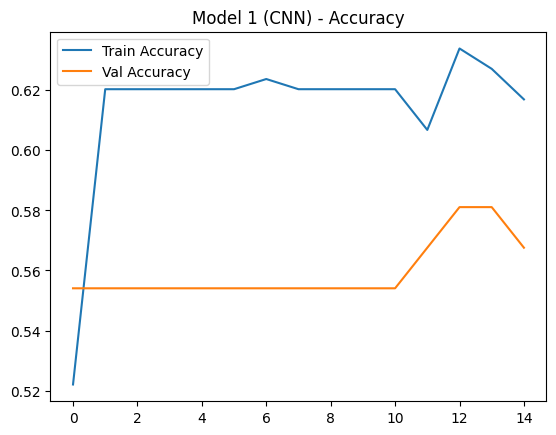

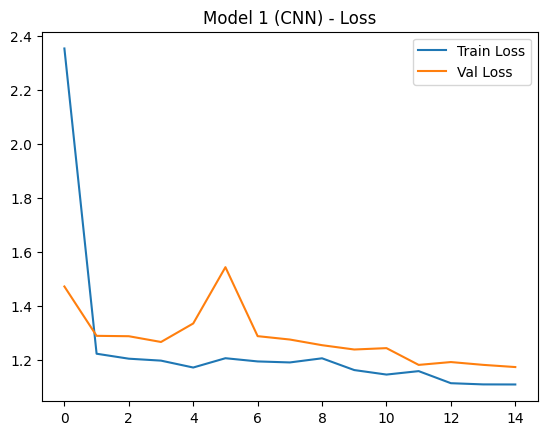

In [33]:
plot_history(history1, "Model 1 (CNN)")


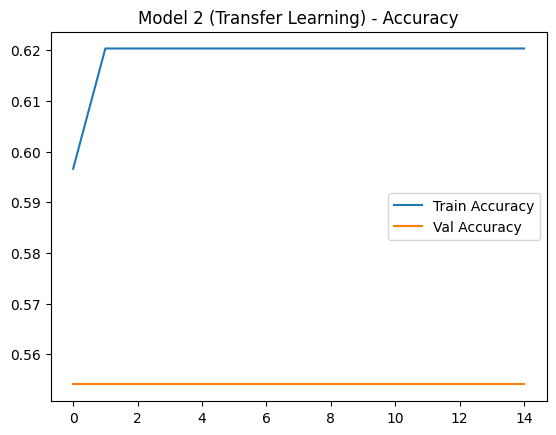

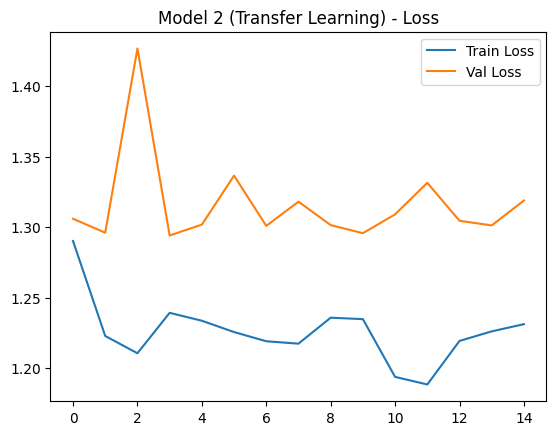

In [34]:
plot_history(history2, "Model 2 (Transfer Learning)")


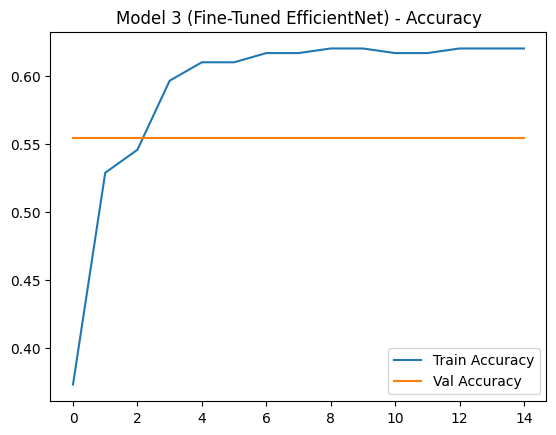

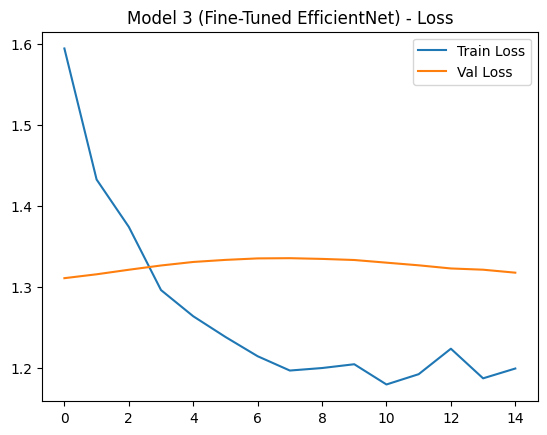

In [35]:
plot_history(history3, "Model 3 (Fine-Tuned EfficientNet)")


adding confusion metrices

In [37]:
import numpy as np

# Predict probabilities
pred_probs = model_2.predict(val_data)

# Convert to class index
y_pred = np.argmax(pred_probs, axis=1)


5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step


In [38]:
y_true = val_data.classes


In [39]:
class_labels = list(val_data.class_indices.keys())
print(class_labels)


['0', '1', '2', '3', '4']


In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)


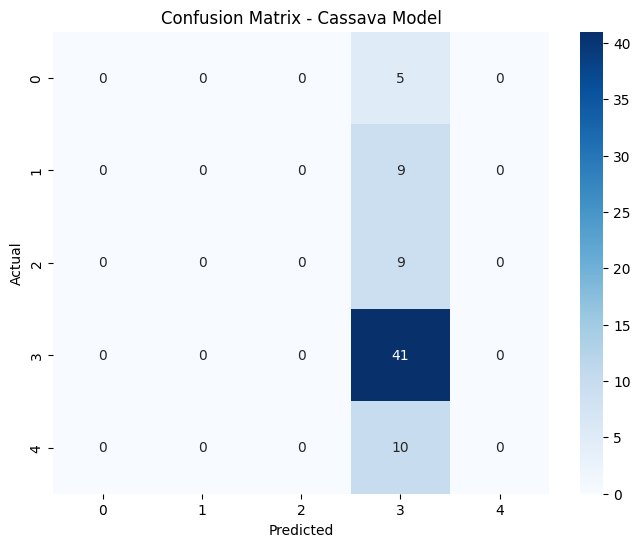

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Cassava Model")
plt.show()
